In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
import yaml
import numpy as np
from pathlib import Path

with open("../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

name = (
    f"model_{cfg['model']['type']}"
    f"_latent{cfg['model']['latent']}"
    f"_beta{cfg['train']['beta']}"
    f"_lr{cfg['optimizer']['lr']}"
    f"_epoch{cfg['train']['epochs']}"
)

inference_dir = Path(cfg["output"]["inference_dir"]) / name

train = np.load(inference_dir / "train.npz")
val   = np.load(inference_dir / "val.npz")
kaon  = np.load(inference_dir / "kaon.npz")

train_latents = train["latents"]
train_recon   = train["recon"]
train_re      = train["re"]

val_latents   = val["latents"]
val_recon     = val["recon"]
val_re        = val["re"]

kaon_latents  = kaon["latents"]
kaon_recon    = kaon["recon"]
kaon_re       = kaon["re"]

In [8]:
all_latents = np.concatenate([train_latents, kaon_latents, val_latents], axis=0)
all_re = np.concatenate([train_re, kaon_re, val_re])

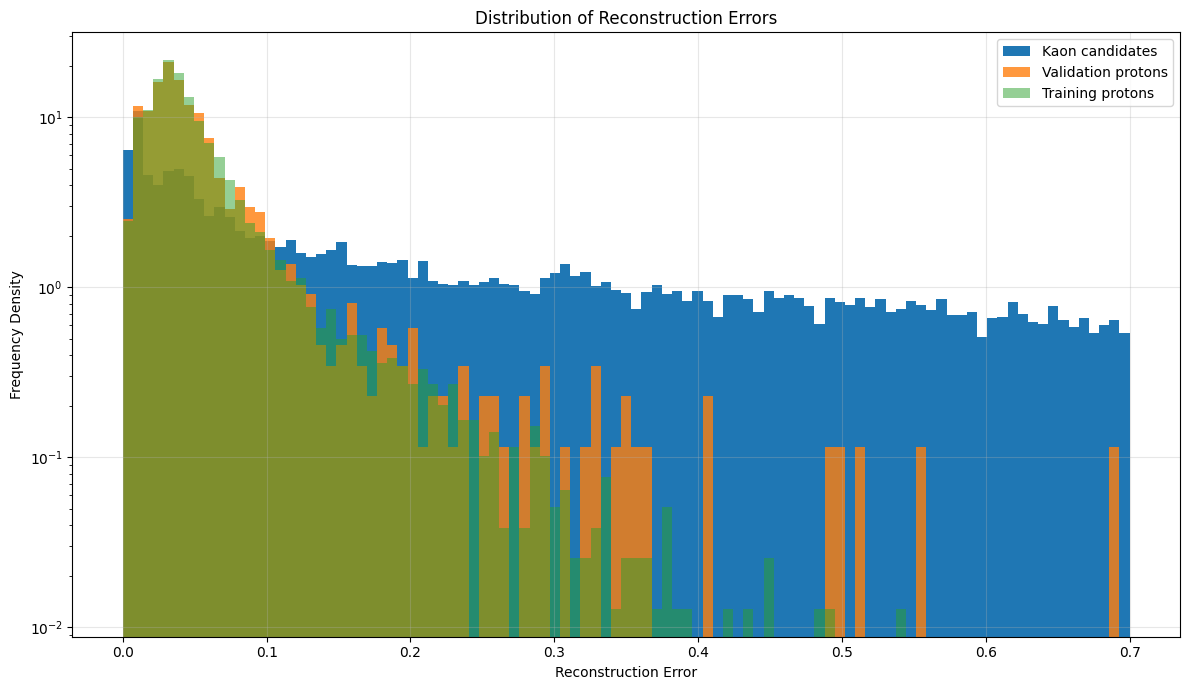

In [ ]:
plt.figure(figsize=(12, 7))

bins = np.linspace(0, 0.7, 100)

plt.hist(kaon_re, bins=bins, alpha=1, label='Kaon candidates', density=True)
plt.hist(val_re, bins=bins, alpha=0.8, label='Validation protons', density=True)
plt.hist(train_re, bins=bins, alpha=0.5, label='Training protons', density=True)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency Density")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

# TSNE

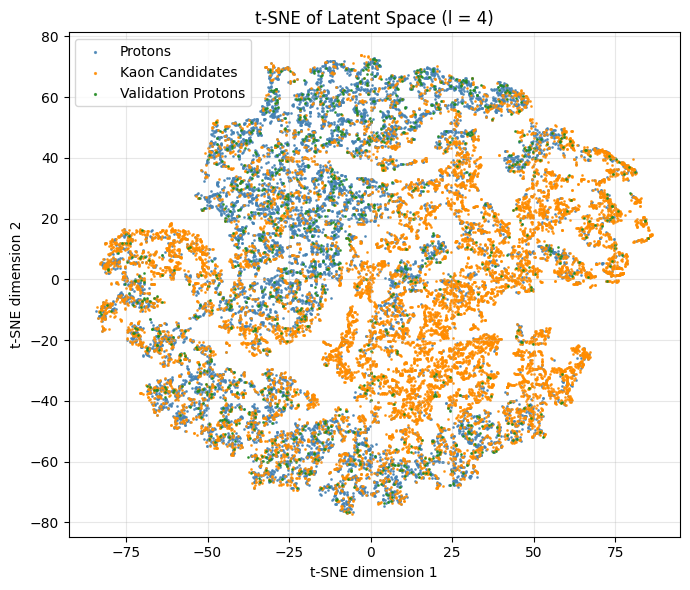

NameError: name 'mcolors' is not defined

<Figure size 700x600 with 0 Axes>

In [9]:
from sklearn.manifold import TSNE

labels = np.concatenate([
    np.zeros(len(train_latents)),          # 0 = protons
    np.ones(len(kaon_latents)),         # 1 = kaons
    np.full(len(val_latents), 2)     # 2 = validation
])

tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=50,
    max_iter=2000,
    init='random',
    random_state=42
)
latents_tsne = tsne.fit_transform(all_latents)

plt.figure(figsize=(7, 6))
colours = ['steelblue', 'darkorange', 'forestgreen']
labels_text = ['Protons', 'Kaon Candidates', 'Validation Protons']

for i, (colour, label_name) in enumerate(zip(colours, labels_text)):
    plt.scatter(latents_tsne[labels == i, 0],
                latents_tsne[labels == i, 1],
                color=colour,
                alpha=0.8,
                s=1,
                label=label_name)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=1.3)
plt.title("t-SNE of Latent Space (l = 4)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,6))
sc = plt.scatter(latents_tsne[:, 0], latents_tsne[:, 1],
                 c=all_re,
                 cmap='viridis',
                 norm=mcolors.LogNorm(vmin=all_re.min()+1e-8, vmax=all_re.max()),
                 s=1)
plt.colorbar(sc, label='Reconstruction Error (log scale)')
plt.title("t-SNE coloured by Reconstruction Error (log colour scale)")
plt.tight_layout()
plt.show()

# UMAP